<a href="https://colab.research.google.com/github/hai562k2/sentiment-analysis/blob/main/sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Cài/nhập thư viện cần thiết
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

MODEL_NAME = "vinai/phobert-base"  # sẽ tải lần đầu (cần mạng)
MAX_LENGTH = 256
LABEL_EN = {"positive": 0, "negative": 1, "neutral": 2}
LABEL_VI = {"positive": "Tích cực", "negative": "Tiêu cực", "neutral": "Trung tính"}
id2label = {v: k for k, v in LABEL_EN.items()}
label2id = LABEL_EN

def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_label(x):
    if pd.isna(x):
        return None
    t = str(x).strip().lower()
    if t in {"pos", "positive", "good", "+", "tich cuc", "tích cực"}:
        return "positive"
    if t in {"neg", "negative", "bad", "-", "tieu cuc", "tiêu cực"}:
        return "negative"
    if t in {"neu", "neutral", "neu.", "trung tinh", "trung tính"}:
        return "neutral"
    return None

def map_rate_to_label(rate):
    if pd.isna(rate):
        return None
    try:
        r = float(rate)
    except Exception:
        return None
    if r >= 4:
        return "positive"
    if r <= 2:
        return "negative"
    return "neutral"


Đọc 31460 dòng từ data - data.csv
                       comment     label  label_id
0               Áo bao đẹp ạ!!  positive         0
1                  Tuyệt vời !  positive         0
2   2day ao khong giong trong.  negative         1
3  Mùi thơm,bôi lên da mềm da.  positive         0
4            Vải đẹp, dày dặn.  positive         0
label
positive    20093
negative     6669
neutral      4698
Name: count, dtype: int64
Số mẫu sau tiền xử lý: 31460


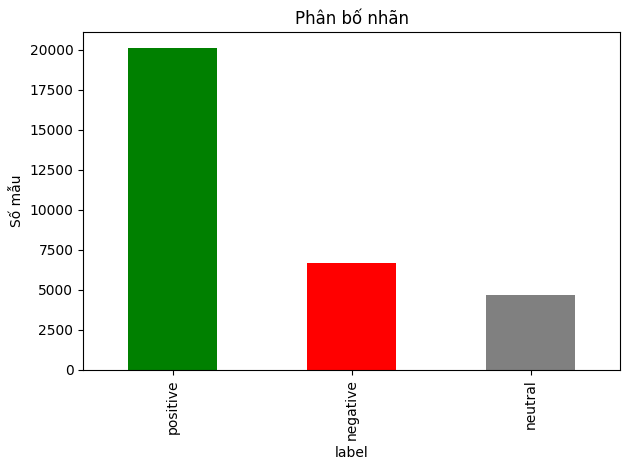

In [14]:
# Đọc và chuẩn hóa dữ liệu huấn luyện + biểu đồ phân bố nhãn
candidates = [
    Path('data - data.csv'),
    Path('data.csv'),
    Path('vietnamese_comments.csv'),
    Path('data.xlsx'),
]
existing = [p for p in candidates if p.exists()]
if not existing:
    raise FileNotFoundError("Không tìm thấy file dữ liệu. Đặt file thành 'data - data.csv' hoặc 'data.xlsx'.")
data_path = existing[0]

if data_path.suffix.lower() in {'.xlsx', '.xls'}:
    df_raw = pd.read_excel(data_path)
else:
    df_raw = pd.read_csv(data_path)
print(f"Đọc {len(df_raw)} dòng từ {data_path}")

# Bỏ cột rác
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains('^Unnamed')]
if 'comment' not in df_raw.columns:
    raise ValueError("File dữ liệu cần có cột 'comment'.")

label_col = df_raw['label'].apply(normalize_label) if 'label' in df_raw.columns else None
rate_col = df_raw['rate'] if 'rate' in df_raw.columns else None
labels = label_col.copy() if label_col is not None else None

if labels is None:
    if rate_col is None:
        raise ValueError("Cần cột 'label' hoặc 'rate' để tạo nhãn.")
    labels = rate_col.apply(map_rate_to_label)
    print("Tạo nhãn từ rate: >=4 tích cực, <=2 tiêu cực, còn lại trung tính")
else:
    if rate_col is not None:
        fill_mask = labels.isna()
        if fill_mask.any():
            labels.loc[fill_mask] = rate_col[fill_mask].apply(map_rate_to_label)
            print(f"Bổ sung nhãn từ rate cho {fill_mask.sum()} dòng")

labels = labels.replace({None: pd.NA})

df = pd.DataFrame({
    'comment': df_raw['comment'].apply(clean_text),
    'label': labels,
}).dropna(subset=['comment', 'label'])

df['label_id'] = df['label'].map(label2id)
df = df.dropna(subset=['label_id'])
df['label_id'] = df['label_id'].astype(int)

print(df.head())
print(df['label'].value_counts())
print(f"Số mẫu sau tiền xử lý: {len(df)}")

if df['label'].nunique() < 2:
    raise ValueError("Cần >=2 lớp để huấn luyện.")

# Biểu đồ phân bố nhãn
ax = df['label'].value_counts().reindex(label2id.keys()).plot(kind='bar', color=['green', 'red', 'gray'])
ax.set_ylabel('Số mẫu')
ax.set_title('Phân bố nhãn')
plt.tight_layout()
plt.show()

In [15]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)
from sklearn.model_selection import train_test_split # Thêm dòng này để import train_test_split

# Huấn luyện với class weight (mặc định chạy CPU, bật GPU trên Colab nếu có)
USE_CPU_ONLY = False  # Đổi False nếu đang chạy có GPU (vd: Colab)
device = torch.device('cuda' if torch.cuda.is_available() and not USE_CPU_ONLY else 'cpu')
print('Device:', device)

class CommentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=158):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_length)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['comment'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

print('Đang tải tokenizer + model PhoBERT (cần mạng lần đầu)...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id,
)
model.to(device)

train_dataset = CommentDataset(train_texts, train_labels, tokenizer, max_length=MAX_LENGTH)
test_dataset = CommentDataset(test_texts, test_labels, tokenizer, max_length=MAX_LENGTH)

counts = Counter(train_labels)
weights = torch.tensor([
    1.0 / counts.get(label2id['positive'], 1),
    1.0 / counts.get(label2id['negative'], 1),
    1.0 / counts.get(label2id['neutral'], 1),
], dtype=torch.float)
weights = weights / weights.sum() * len(weights)

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        weight = self.class_weights.to(model.device) if self.class_weights is not None else None
        loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='./phobert-output',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',         # <- dùng eval_strategy
    logging_steps=50,
    save_strategy='no',
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to='none',
    use_cpu=False  # Đặt False trên Colab nếu muốn GPU
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    class_weights=weights,
)

trainer.train()

Device: cuda
Đang tải tokenizer + model PhoBERT (cần mạng lần đầu)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss
1,0.666500,0.687764


TrainOutput(global_step=3146, training_loss=0.7386632611322616, metrics={'train_runtime': 715.0996, 'train_samples_per_second': 35.195, 'train_steps_per_second': 4.399, 'total_flos': 1875381996327840.0, 'train_loss': 0.7386632611322616, 'epoch': 1.0})

### 4. Đánh giá mô hình

Độ chính xác (Accuracy): 0.7816

Báo cáo phân loại:
              precision    recall  f1-score   support

    positive       0.93      0.85      0.89      4019
    negative       0.73      0.79      0.76      1334
     neutral       0.39      0.48      0.43       939

    accuracy                           0.78      6292
   macro avg       0.68      0.71      0.69      6292
weighted avg       0.80      0.78      0.79      6292



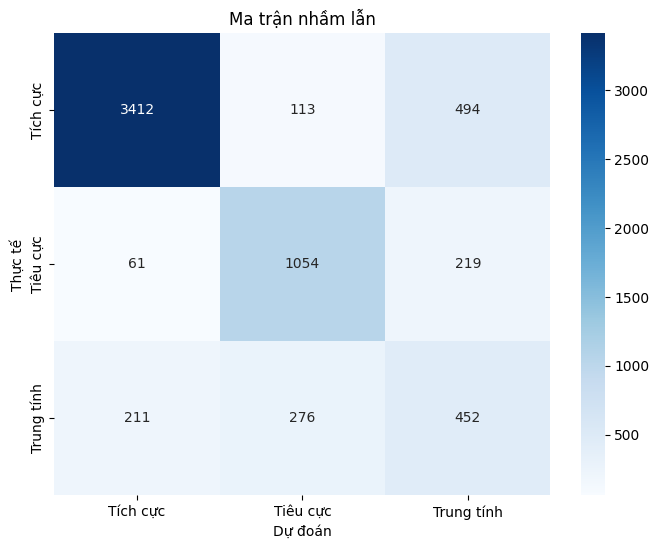

In [18]:
import seaborn as sns
# Dự đoán trên tập kiểm tra
predictions = trainer.predict(test_dataset)

# Lấy các nhãn dự đoán và nhãn thật
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels.values

# Tính toán độ chính xác
accuracy = accuracy_score(y_true, y_pred)
print(f"Độ chính xác (Accuracy): {accuracy:.4f}")

# Hiển thị báo cáo phân loại
print("\nBáo cáo phân loại:")
print(classification_report(y_true, y_pred, target_names=list(label2id.keys())))

# Hiển thị ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_VI[id2label[i]] for i in sorted(id2label.keys())],
            yticklabels=[LABEL_VI[id2label[i]] for i in sorted(id2label.keys())])
plt.title('Ma trận nhầm lẫn')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

### 5. Dự đoán trên dữ liệu mới

In [19]:
def predict_sentiment(text: str):
    cleaned_text = clean_text(text)
    inputs = tokenizer(cleaned_text, truncation=True, padding=True, max_length=MAX_LENGTH, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_id = torch.argmax(logits, dim=1).item()

    predicted_label = id2label[predicted_class_id]
    return LABEL_VI[predicted_label]

print("Hàm `predict_sentiment(text)` đã được định nghĩa. Bạn có thể sử dụng nó để dự đoán cảm xúc của một đoạn văn bản.")

Hàm `predict_sentiment(text)` đã được định nghĩa. Bạn có thể sử dụng nó để dự đoán cảm xúc của một đoạn văn bản.


In [24]:
# Ví dụ dự đoán:
comment1 = "Sản phẩm này rất tốt, tôi rất hài lòng!"
comment2 = "Chất liệu quá chán."
comment3 = "Sản phẩm bình thường, không có gì đặc biệt."

print(f"'{comment1}' -> {predict_sentiment(comment1)}")
print(f"'{comment2}' -> {predict_sentiment(comment2)}")
print(f"'{comment3}' -> {predict_sentiment(comment3)}")

'Sản phẩm này rất tốt, tôi rất hài lòng!' -> Tích cực
'Chất liệu quá chán.' -> Tiêu cực
'Sản phẩm bình thường, không có gì đặc biệt.' -> Trung tính
